# Stock Price Forecasting — Notebook Template

**Dành cho:** Tất cả thành viên nhóm  
**Dữ liệu:** 5 mã VCB, FPT, HPG, VIC, VNM — Close Price  
**Chỉ số đánh giá:** RMSE, MAE, MAPE, R²

---

## Hướng dẫn sử dụng
1. **Copy** file này, đặt tên theo model (ví dụ: `02_arima_svr.ipynb`, `03_lstm_gru.ipynb`)
2. Điền code vào các ô có comment `# ── TODO ──`
3. Các hàm `compute_metrics`, `plot_predictions`, `load_split` đã có sẵn → **không cần viết lại**
4. Chạy cell cuối để in bảng tổng hợp

## Phân công model
| Thành viên | Model 1 | Model 2 |
|---|---|---|
| TV1 | Linear Regression + lag features | *(tự chọn)* |
| TV2 | ARIMA / SARIMA | SVR hoặc Random Forest |
| TV3 | LSTM | GRU |
| TV4 | Facebook Prophet | XGBoost hoặc Transformer |

## Cấu trúc splits sẵn có
```
data/processed/splits/
├── 70_30/  {TICKER}_train.csv  /  {TICKER}_test.csv
└── 80_20/  {TICKER}_train.csv  /  {TICKER}_test.csv
```

---
## Section 0 — Setup chung

In [1]:
%pip install numpy matplotlib pandas scikit-learn matplotlib statsmodels

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import warnings
warnings.filterwarnings('ignore')

import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ── TODO: thêm import model của bạn ở đây ──
from statsmodels.tsa.arima.model import ARIMA

%matplotlib inline
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

In [3]:
# ── Cấu hình đường dẫn ──
ROOT       = Path('..').resolve()
SPLITS_DIR = ROOT / 'data' / 'processed' / 'splits'
FEATURED_DIR = ROOT / 'data' / 'processed' / 'featured'

TICKERS = ['VCB', 'FPT', 'HPG', 'VIC', 'VNM']
SPLITS  = ['70_30', '80_20']     # cả hai tỷ lệ

# ── TODO: đặt tên model ──
MODEL_NAME = 'ARIMA'     # dùng trong tiêu đề biểu đồ và tên file

RESULTS_DIR = ROOT / 'results' / MODEL_NAME.lower().replace(' ', '_')
PLOTS_DIR   = RESULTS_DIR / 'plots'
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

# Đọc split_info để biết ngày cắt
split_info = json.loads((SPLITS_DIR / 'split_info.json').read_text())
print('Split info loaded.')
for entry in split_info:
    t = entry['ticker']
    for label, s in entry['splits'].items():
        print(f"  {t} [{label}]: train → {s['train_end']}  |  test {s['test_start']} → {s['test_end']}  ({s['test_rows']} rows)")

Split info loaded.
  VCB [70_30]: train → 2023-02-20  |  test 2023-02-21 → 2026-04-29  (795 rows)
  VCB [80_20]: train → 2024-03-12  |  test 2024-03-13 → 2026-04-29  (530 rows)
  FPT [70_30]: train → 2023-02-20  |  test 2023-02-21 → 2026-04-29  (795 rows)
  FPT [80_20]: train → 2024-03-12  |  test 2024-03-13 → 2026-04-29  (530 rows)
  HPG [70_30]: train → 2023-02-20  |  test 2023-02-21 → 2026-04-29  (795 rows)
  HPG [80_20]: train → 2024-03-12  |  test 2024-03-13 → 2026-04-29  (530 rows)
  VIC [70_30]: train → 2023-02-20  |  test 2023-02-21 → 2026-04-29  (795 rows)
  VIC [80_20]: train → 2024-03-12  |  test 2024-03-13 → 2026-04-29  (530 rows)
  VNM [70_30]: train → 2023-02-20  |  test 2023-02-21 → 2026-04-29  (795 rows)
  VNM [80_20]: train → 2024-03-12  |  test 2024-03-13 → 2026-04-29  (530 rows)


---
## Section 1 — Hàm tiện ích (dùng chung, không sửa)

In [4]:
def load_split(ticker: str, split: str) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Load train/test DataFrames cho một mã và một tỷ lệ split."""
    base = SPLITS_DIR / split
    train = pd.read_csv(base / f'{ticker}_train.csv', parse_dates=['date'])
    test  = pd.read_csv(base / f'{ticker}_test.csv',  parse_dates=['date'])
    return train.sort_values('date').reset_index(drop=True), \
           test.sort_values('date').reset_index(drop=True)

In [5]:
# ── compute_metrics — single source of truth tại src/metrics.py ──
# Trả về dict gồm: RMSE, MAE, MAPE (%), R²
# Truyền `prev_close` (giá đóng cửa của ngày liền trước) để có thêm "Directional Accuracy (%)".
import sys as _sys
_sys.path.insert(0, str(ROOT))
from src.metrics import compute_metrics  # noqa: E402


In [6]:
def plot_predictions(
    dates,
    y_true,
    y_pred,
    ticker: str,
    split: str,
    model_name: str,
    metrics: dict,
    save: bool = True,
) -> None:
    """Vẽ biểu đồ Actual vs Predicted và lưu file PNG."""
    fig, ax = plt.subplots(figsize=(14, 4.5))

    ax.plot(dates, y_true, label='Actual',    color='#2563EB', linewidth=1.2, alpha=0.85)
    ax.plot(dates, y_pred, label='Predicted', color='#DC2626', linewidth=1.2, alpha=0.85, linestyle='--')

    ratio_label = split.replace('_', '/')
    subtitle = (f"RMSE={metrics['RMSE']:,.2f}  "
                f"MAE={metrics['MAE']:,.2f}  "
                f"MAPE={metrics['MAPE (%)']:.2f}%  "
                f"R²={metrics['R²']:.4f}")
    ax.set_title(f"{model_name} — {ticker}  (Split {ratio_label})\n{subtitle}", pad=10)
    ax.set_xlabel('Ngày')
    ax.set_ylabel('Giá đóng cửa (VND × nghìn)')
    ax.legend(loc='upper left')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    plt.xticks(rotation=35, ha='right')
    ax.grid(axis='y', linestyle=':', alpha=0.5)
    plt.tight_layout()

    if save:
        fname = PLOTS_DIR / f"{ticker}_{split}_{model_name.lower().replace(' ', '_')}.png"
        fig.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()

In [7]:
def build_results_table(all_results: list[dict]) -> pd.DataFrame:
    """Tạo bảng tổng hợp RMSE/MAE/MAPE/R² (+ Directional Accuracy nếu có) cho tất cả mã và splits."""
    df = pd.DataFrame(all_results)
    cols = ['Ticker', 'Split', 'Model', 'RMSE', 'MAE', 'MAPE (%)', 'R²']
    if 'Directional Accuracy (%)' in df.columns:
        cols.append('Directional Accuracy (%)')
    df = df[cols].sort_values(['Split', 'Ticker']).reset_index(drop=True)
    df[['RMSE', 'MAE']] = df[['RMSE', 'MAE']].round(2)
    df['MAPE (%)'] = df['MAPE (%)'].round(3)
    df['R²'] = df['R²'].round(4)
    if 'Directional Accuracy (%)' in df.columns:
        df['Directional Accuracy (%)'] = df['Directional Accuracy (%)'].round(2)
    return df


---
## Section 2 — Feature Engineering *(TODO)*

Điền hàm chuẩn bị features cho model của bạn vào đây.  
- **Input:** `train_df`, `test_df` (DataFrame từ `load_split`)
- **Output:** `X_train, y_train, X_test, y_test` (hoặc format model yêu cầu)

> **Lưu ý:** Không dùng dữ liệu tương lai trong train (không shuffle, không look-ahead).

In [8]:
# ── TODO: viết hàm chuẩn bị features ──

def prepare_data(train_df: pd.DataFrame, test_df: pd.DataFrame):
    """
    Chuẩn bị dữ liệu đầu vào cho model.
    """
    target_col = 'close'

    # ARIMA thường chỉ cần chuỗi thời gian của mục tiêu
    y_train = train_df[target_col].values
    y_test  = test_df[target_col].values

    return y_train, y_test

---
## Section 3 — Huấn luyện & Dự báo *(TODO)*

Điền logic train và predict của model vào hàm `train_and_predict`.

In [9]:
# ── TODO: viết hàm train và predict ──

def train_and_predict(train_df: pd.DataFrame, test_df: pd.DataFrame) -> np.ndarray:
    """
    Train model bằng phương pháp Rolling Forecast (Dự báo cuốn chiếu).
    Mô hình sẽ dự báo 1 ngày, sau đó được "nhìn thấy" giá thực tế của ngày đó 
    để cập nhật lại dữ liệu và tiếp tục dự báo ngày tiếp theo.
    """
    
    history = list(train_df['close'].values)
    test_data = test_df['close'].values
    predictions = []
    
    
    import warnings
    from statsmodels.tools.sm_exceptions import ConvergenceWarning
    warnings.simplefilter('ignore', ConvergenceWarning)
    
  
    for t in range(len(test_data)):
        # Khởi tạo mô hình ARIMA với tập history hiện tại
        model = ARIMA(history, order=(5, 1, 0))
        fitted_model = model.fit()
        
        # Dự báo 1 bước duy nhất (cho ngày t)
        yhat = fitted_model.forecast()[0]
        predictions.append(yhat)
        
        # Thêm giá trị THỰC TẾ của ngày t vào history 
        history.append(test_data[t])
        
    return np.array(predictions)

---
## Section 4 — Vòng lặp chính: Train → Evaluate → Plot

**Không cần sửa** — gọi `train_and_predict` và `compute_metrics` cho mọi (ticker, split).


  Split: 70/30

  ▶  VCB ...
     RMSE=0.88  MAE=0.57  MAPE=0.94%  R²=0.9520  DA=52.2%


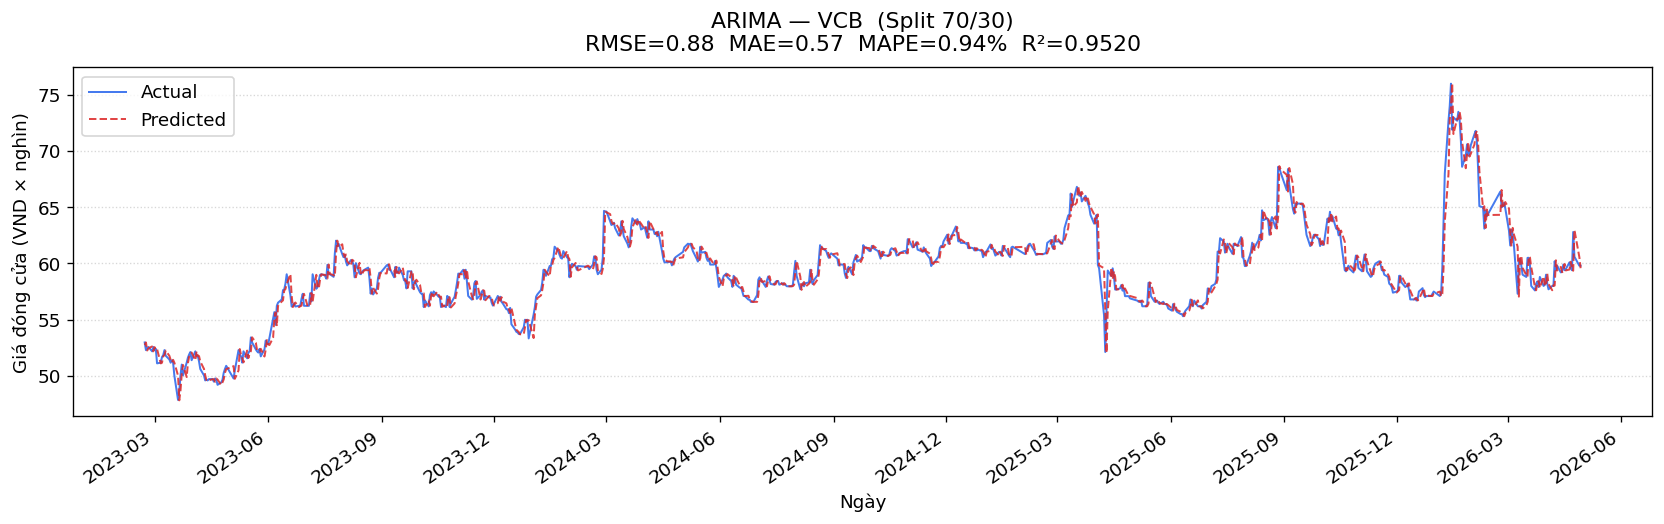


  ▶  FPT ...
     RMSE=1.59  MAE=1.10  MAPE=1.22%  R²=0.9951  DA=53.8%


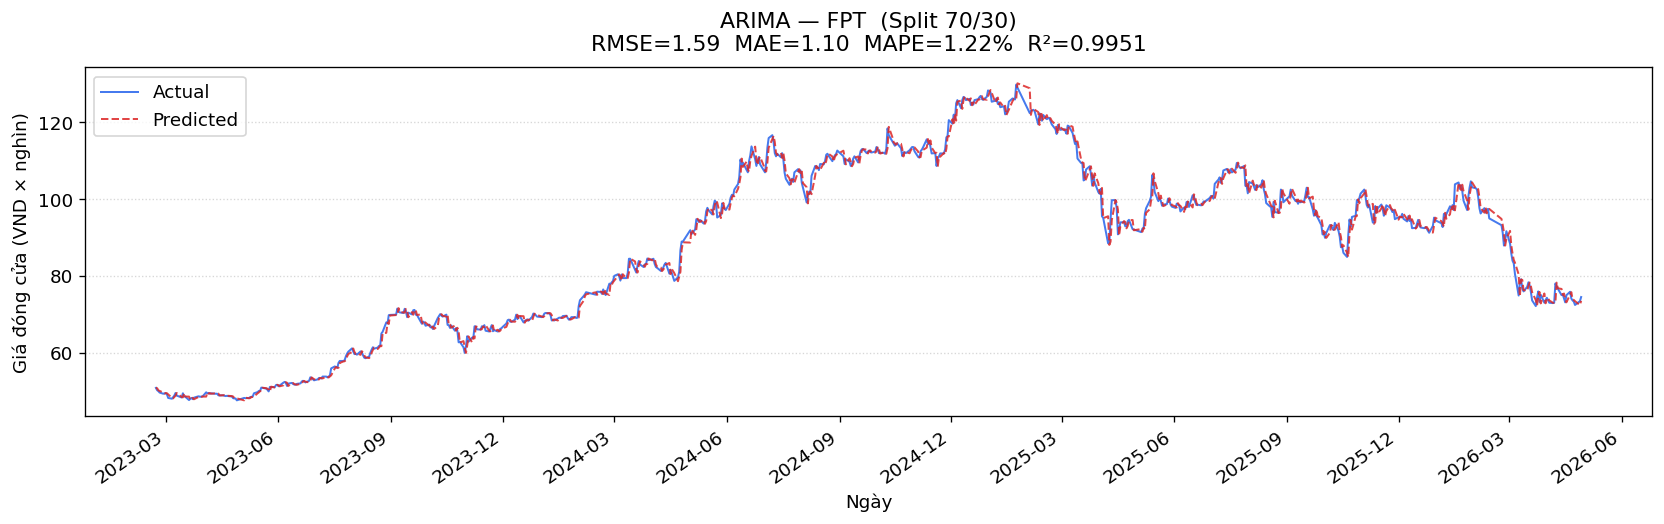


  ▶  HPG ...
     RMSE=0.35  MAE=0.25  MAPE=1.23%  R²=0.9866  DA=48.2%


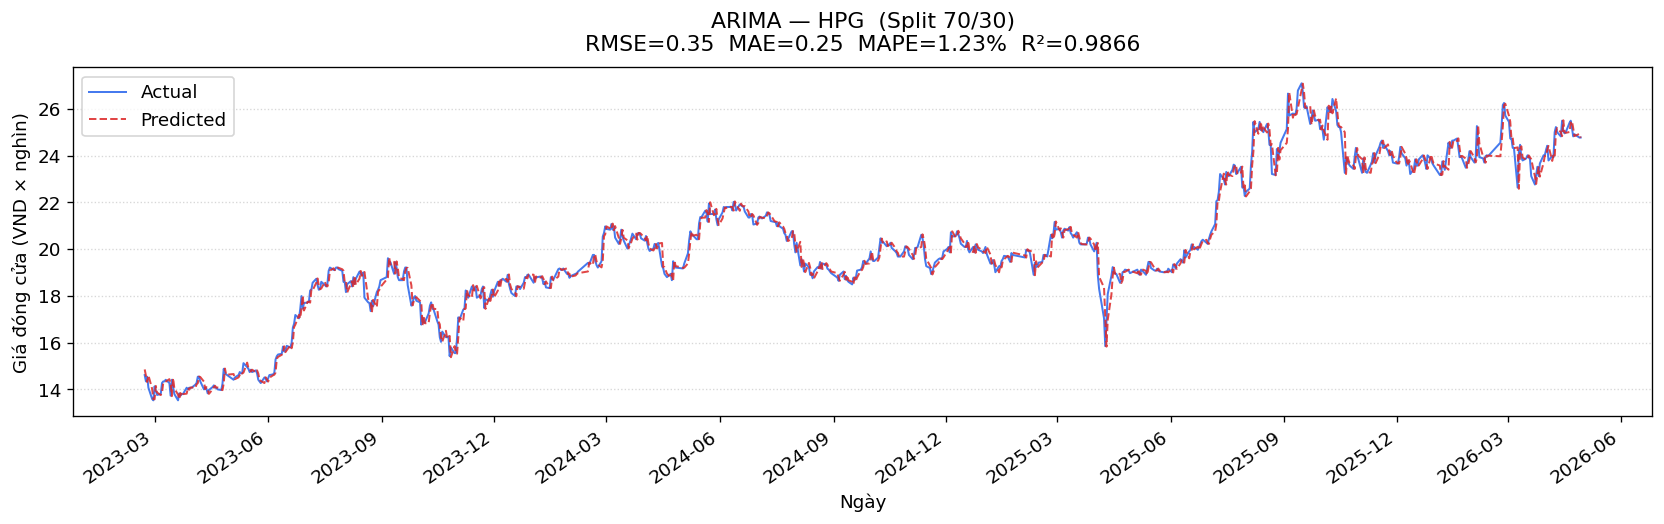


  ▶  VIC ...
     RMSE=2.46  MAE=1.12  MAPE=1.63%  R²=0.9972  DA=53.2%


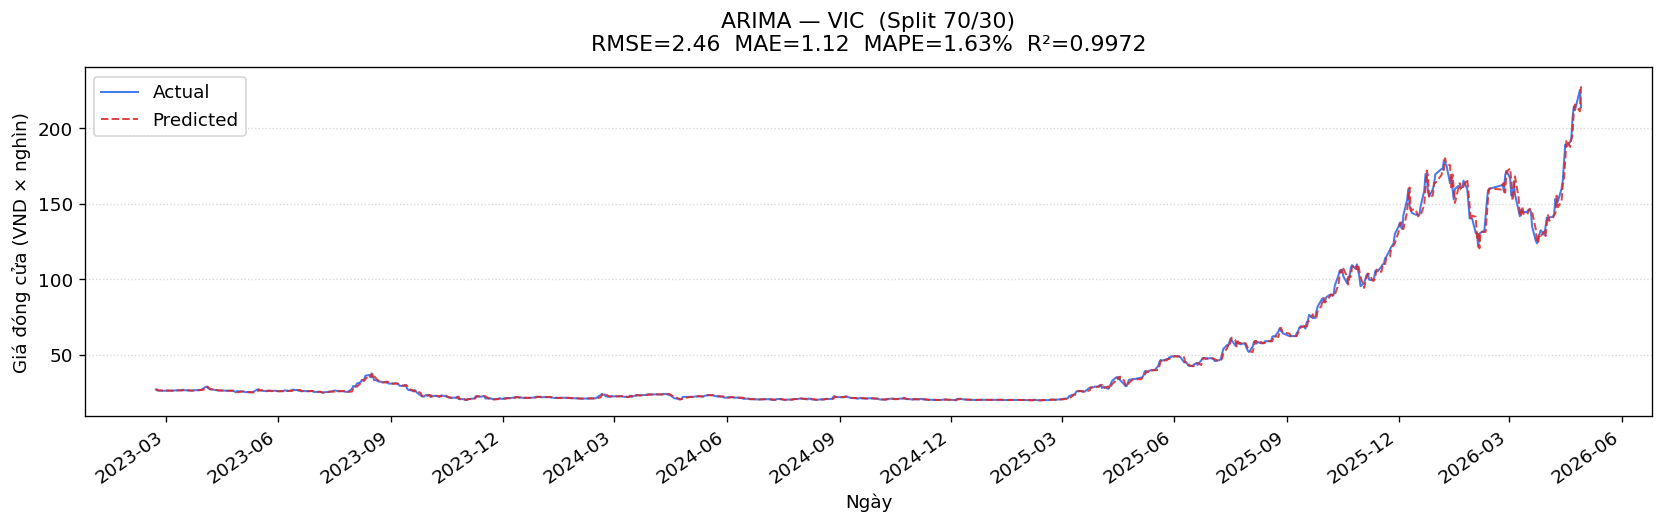


  ▶  VNM ...
     RMSE=0.89  MAE=0.61  MAPE=1.00%  R²=0.9479  DA=53.5%


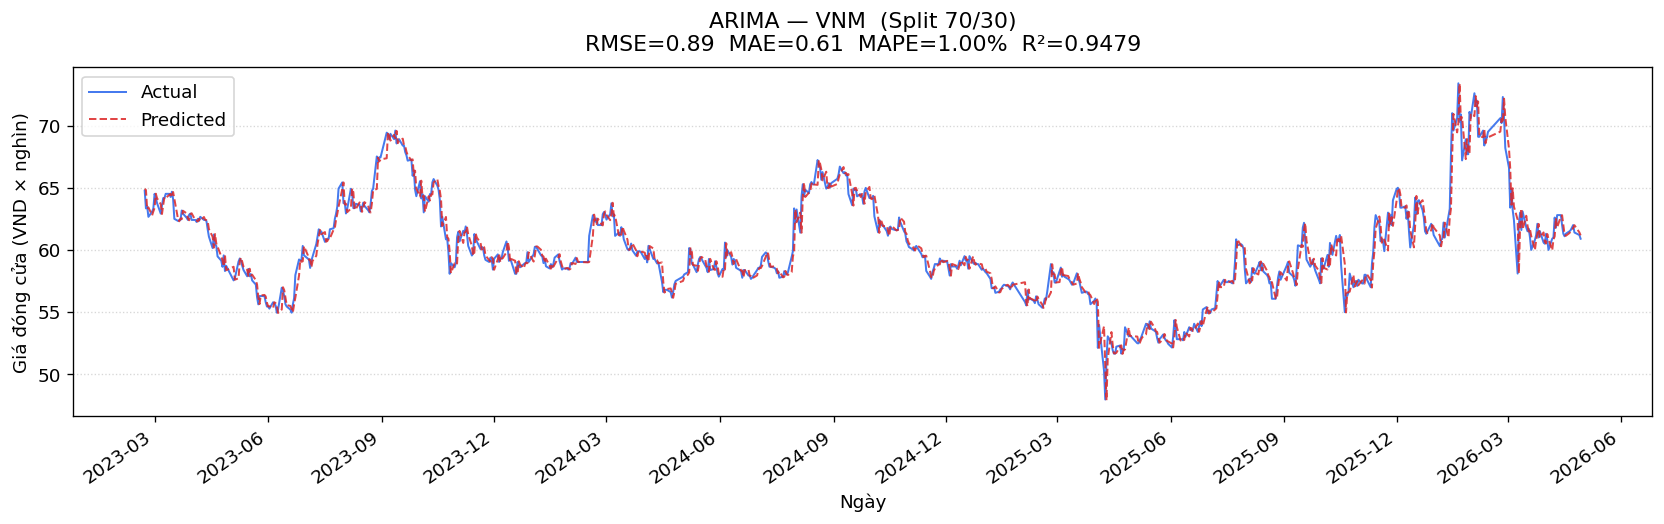


  Split: 80/20

  ▶  VCB ...
     RMSE=0.94  MAE=0.58  MAPE=0.93%  R²=0.9193  DA=52.4%


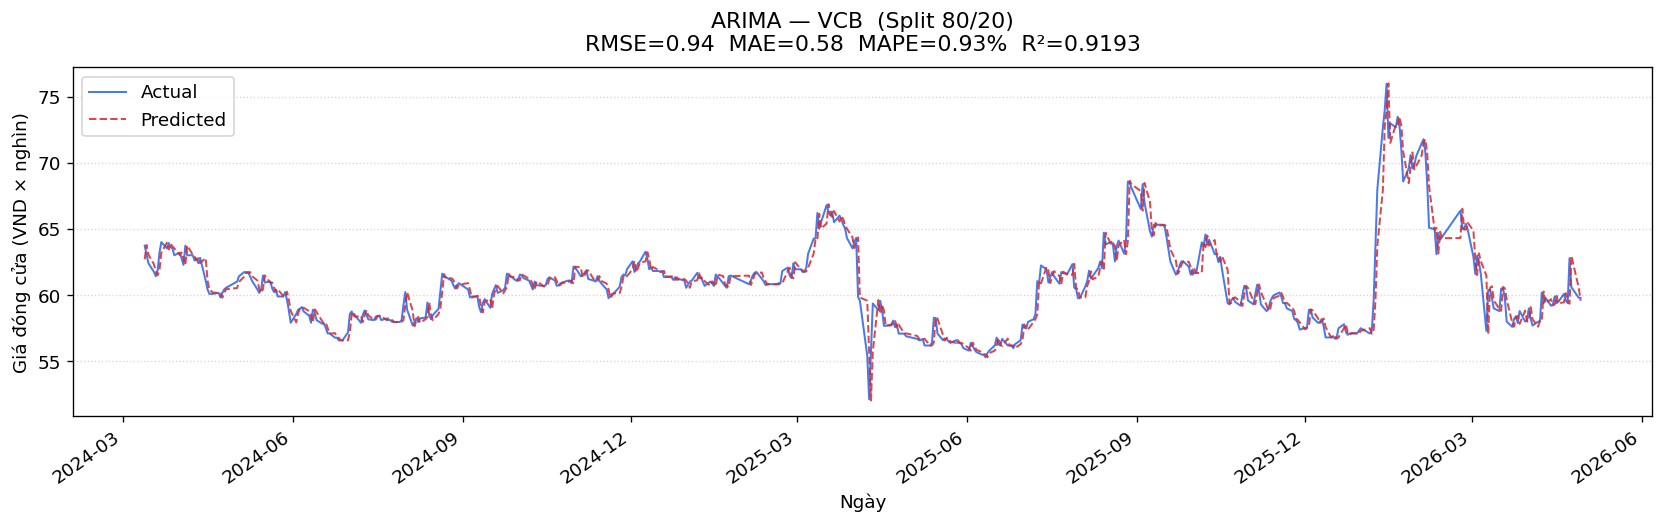


  ▶  FPT ...
     RMSE=1.86  MAE=1.37  MAPE=1.38%  R²=0.9802  DA=54.6%


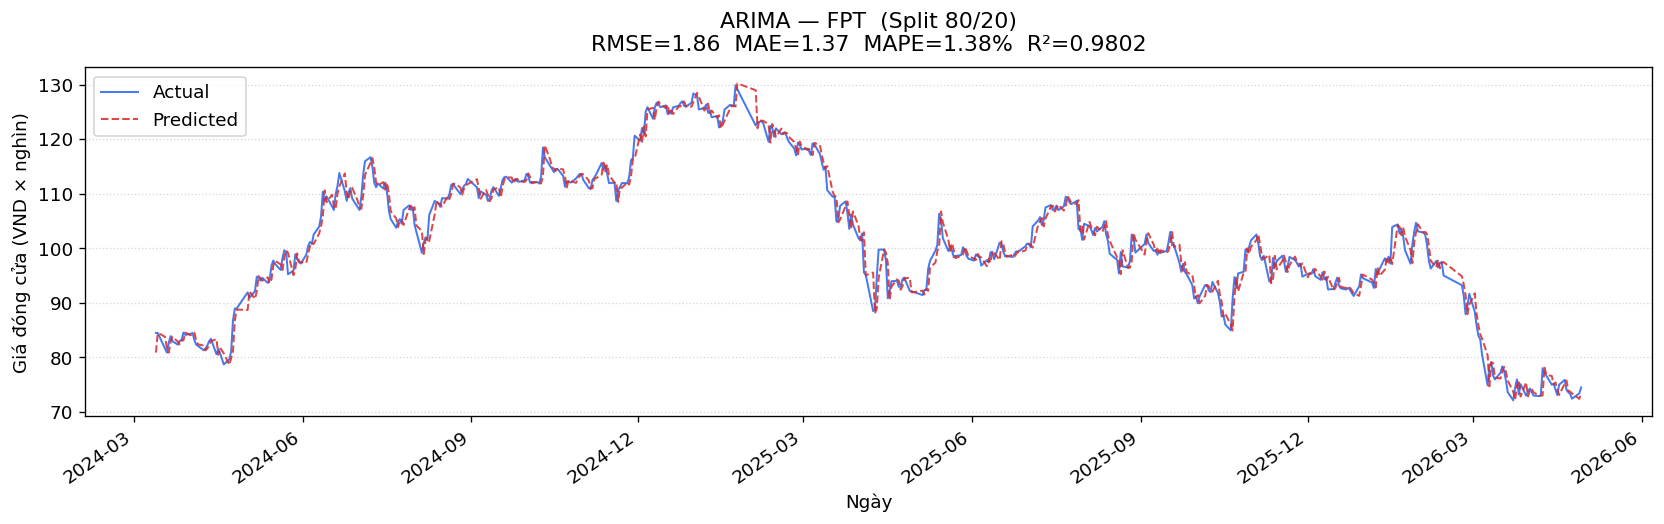


  ▶  HPG ...
     RMSE=0.38  MAE=0.26  MAPE=1.19%  R²=0.9733  DA=49.0%


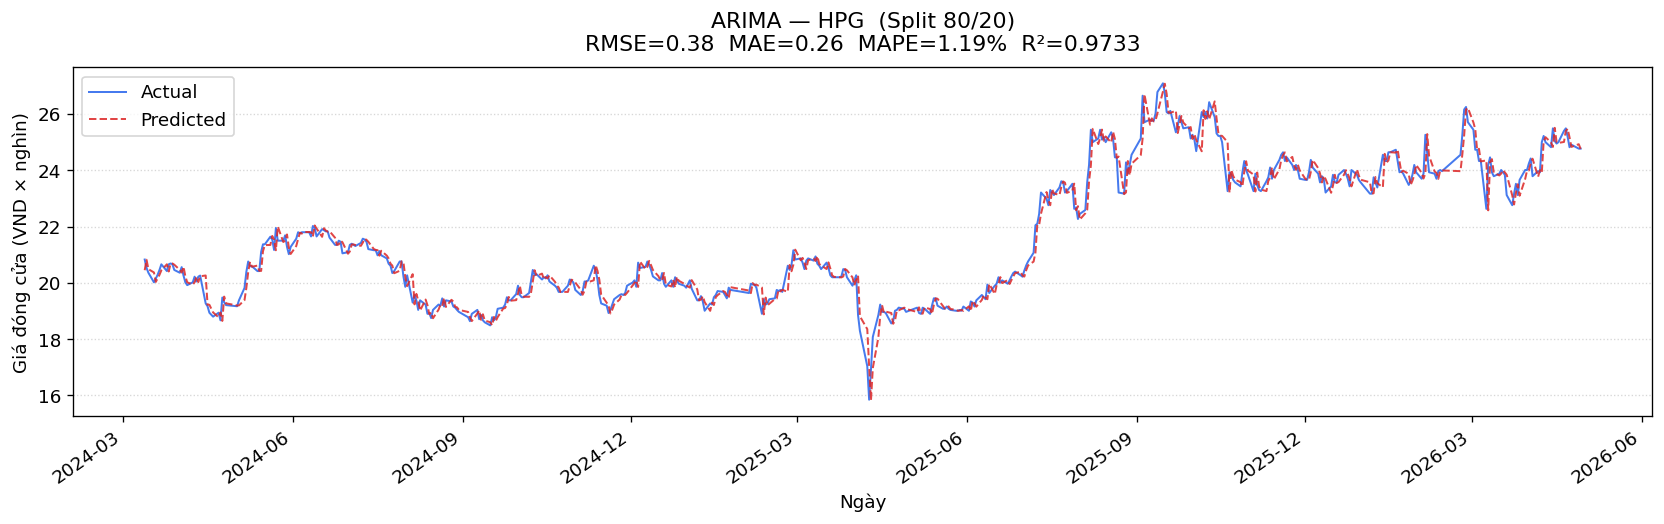


  ▶  VIC ...
     RMSE=2.98  MAE=1.52  MAPE=1.81%  R²=0.9968  DA=55.1%


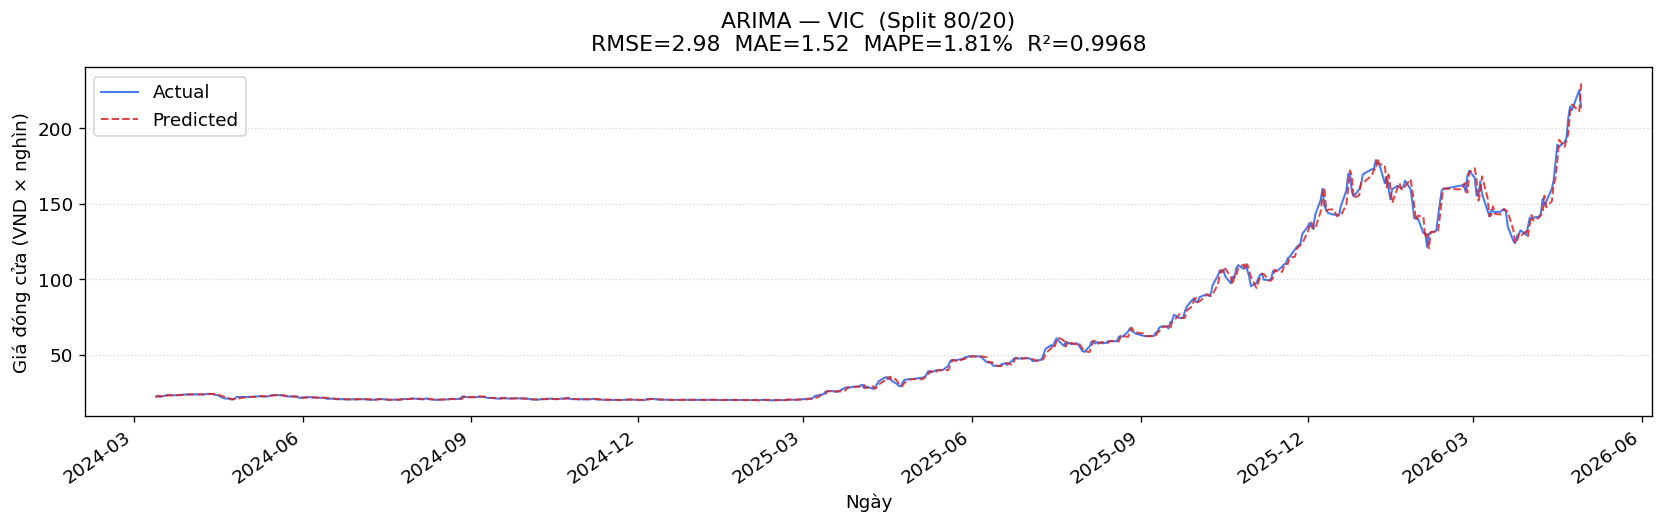


  ▶  VNM ...
     RMSE=0.97  MAE=0.64  MAPE=1.07%  R²=0.9440  DA=54.0%


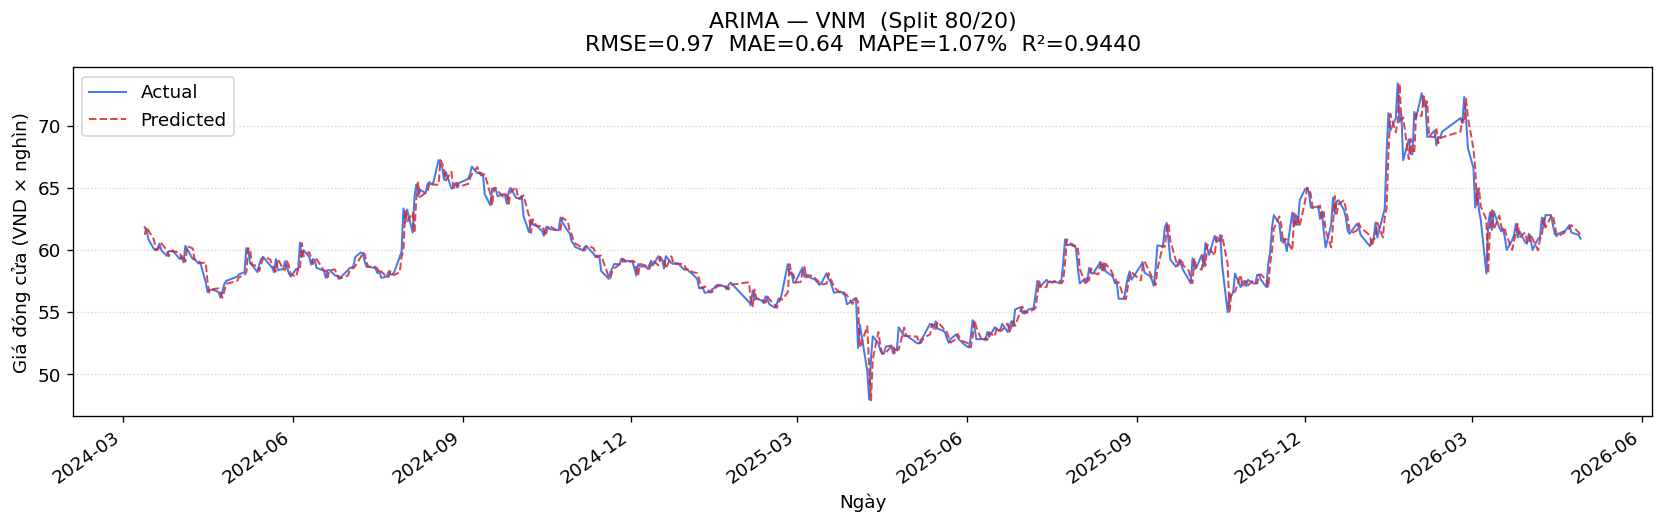

In [10]:
all_results = []

for split in SPLITS:
    print(f"\n{'='*55}")
    print(f"  Split: {split.replace('_', '/')}")
    print(f"{'='*55}")

    for ticker in TICKERS:
        print(f"\n  ▶  {ticker} ...")
        train_df, test_df = load_split(ticker, split)

        # Train & predict
        y_pred = train_and_predict(train_df, test_df)
        y_true = test_df['close'].values

        # prev_close[i] = close của ngày liền trước test row i — dùng cho Directional Accuracy.
        # Test row 0 lấy close cuối train, các row sau lấy y_true[i-1].
        prev_close = np.concatenate([[train_df['close'].iloc[-1]], y_true[:-1]])

        # Metrics (kèm Directional Accuracy %)
        metrics = compute_metrics(y_true, y_pred, prev_close=prev_close)
        da = metrics.get('Directional Accuracy (%)', float('nan'))
        print(f"     RMSE={metrics['RMSE']:,.2f}  MAE={metrics['MAE']:,.2f}  "
              f"MAPE={metrics['MAPE (%)']:.2f}%  R²={metrics['R²']:.4f}  DA={da:.1f}%")

        # Plot
        plot_predictions(
            dates=test_df['date'],
            y_true=y_true,
            y_pred=y_pred,
            ticker=ticker,
            split=split,
            model_name=MODEL_NAME,
            metrics=metrics,
        )

        # Collect result
        all_results.append({'Ticker': ticker, 'Split': split, 'Model': MODEL_NAME, **metrics})


---
## Section 5 — Bảng tổng hợp kết quả

In [11]:
results_df = build_results_table(all_results)

print(f"\n{'─'*75}")
print(f"  Kết quả: {MODEL_NAME}")
print(f"{'─'*75}")
print(results_df.to_string(index=False))

# Lưu CSV để thành viên 1 tổng hợp báo cáo
out_csv = RESULTS_DIR / f'{MODEL_NAME.lower().replace(" ", "_")}_results.csv'
results_df.to_csv(out_csv, index=False)
print(f"\n  Đã lưu → {out_csv}")


───────────────────────────────────────────────────────────────────────────
  Kết quả: ARIMA
───────────────────────────────────────────────────────────────────────────
Ticker Split Model  RMSE  MAE  MAPE (%)     R²  Directional Accuracy (%)
   FPT 70_30 ARIMA  1.59 1.10     1.222 0.9951                     53.80
   HPG 70_30 ARIMA  0.35 0.25     1.230 0.9866                     48.23
   VCB 70_30 ARIMA  0.88 0.57     0.944 0.9520                     52.20
   VIC 70_30 ARIMA  2.46 1.12     1.633 0.9972                     53.17
   VNM 70_30 ARIMA  0.89 0.61     1.002 0.9479                     53.45
   FPT 80_20 ARIMA  1.86 1.37     1.383 0.9802                     54.65
   HPG 80_20 ARIMA  0.38 0.26     1.192 0.9733                     48.99
   VCB 80_20 ARIMA  0.94 0.58     0.934 0.9193                     52.40
   VIC 80_20 ARIMA  2.98 1.52     1.806 0.9968                     55.11
   VNM 80_20 ARIMA  0.97 0.64     1.069 0.9440                     54.05

  Đã lưu → F:\OneDrive\Cao

---
## Section 6 — Export to GitHub Pages Dashboard

Export predictions và metrics vào `docs/data/` để model xuất hiện trên dashboard của nhóm.  
**Không cần sửa** — chạy sau Section 5.

In [ ]:
import json as _json

DOCS_DATA = ROOT / 'docs' / 'data'
DOCS_DATA.mkdir(parents=True, exist_ok=True)

_model_slug = MODEL_NAME.lower().replace(' ', '_')

# ── 1. Export predictions ──
pred_rows = []
for split in SPLITS:
    for ticker in TICKERS:
        train_df, test_df = load_split(ticker, split)
        y_pred = train_and_predict(train_df, test_df)
        y_true = test_df['close'].values
        for i, row in test_df.iterrows():
            pred_rows.append({
                'date':      str(row['date'].date()),
                'actual':    round(float(y_true[i - test_df.index[0]]), 4),
                'predicted': round(float(y_pred[i - test_df.index[0]]), 4),
                'ticker':    ticker,
                'split':     split,
                'model':     MODEL_NAME,
            })

pred_df = pd.DataFrame(pred_rows)
pred_path = DOCS_DATA / f'{_model_slug}_predictions.csv'
pred_df.to_csv(pred_path, index=False)
print(f'Predictions → {pred_path}  ({len(pred_df)} rows)')

# ── 2. Export metrics ──
met_path = DOCS_DATA / f'{_model_slug}_metrics.csv'
results_df.to_csv(met_path, index=False)
print(f'Metrics     → {met_path}')

# ── 3. Update manifest.json ──
manifest_path = DOCS_DATA / 'manifest.json'
if manifest_path.exists():
    manifest = _json.loads(manifest_path.read_text())
else:
    manifest = {'models': [], 'last_updated': ''}

# Remove existing entry for this model if present, then append
manifest['models'] = [m for m in manifest['models'] if m['name'] != MODEL_NAME]
manifest['models'].append({
    'name':        MODEL_NAME,
    'predictions': f'data/{_model_slug}_predictions.csv',
    'metrics':     f'data/{_model_slug}_metrics.csv',
})
manifest['last_updated'] = pd.Timestamp.now().strftime('%Y-%m-%d')
manifest_path.write_text(_json.dumps(manifest, indent=2, ensure_ascii=False))
print(f'Manifest    → {manifest_path}  ({len(manifest["models"])} model(s))')

---
## Ghi chú khi viết báo cáo

- **RMSE** (Root Mean Squared Error): đơn vị VND × nghìn — nhạy với outliers
- **MAE** (Mean Absolute Error): đơn vị VND × nghìn — giải thích trực quan hơn
- **MAPE** (%): sai số phần trăm — dùng để so sánh giữa các mã khác nhau mức giá
- **R²**: hệ số xác định — càng gần 1 càng tốt
- **Directional Accuracy** (%): % lần model dự đoán đúng hướng (tăng/giảm) so với ngày liền trước. Random ≈ 50%; > 55% là có skill về hướng. Quan trọng vì RMSE thấp không nhất thiết kéo theo dự đoán hướng tốt.

Khi viết báo cáo Chương 5, dùng cả 5 chỉ số. Mọi bảng phải thống nhất đơn vị.
Biểu đồ được lưu tại `results/<model_name>/plots/`.
